In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
digits = load_digits()

In [2]:
import torch
import torch.nn as nn
from torch import optim
import numpy as np

X = digits.data
Y = digits.target

7
[[ 0.  0.  3. 11. 16. 16.  4.  0.]
 [ 0.  0.  9. 12. 12. 16.  9.  0.]
 [ 0.  0.  0.  0.  1. 16.  8.  0.]
 [ 0.  0.  0.  9. 14. 16.  9.  0.]
 [ 0.  0.  1. 16. 16. 14.  5.  0.]
 [ 0.  0.  0.  6. 16.  4.  0.  0.]
 [ 0.  0.  0. 11. 14.  0.  0.  0.]
 [ 0.  0.  1. 15.  7.  0.  0.  0.]]


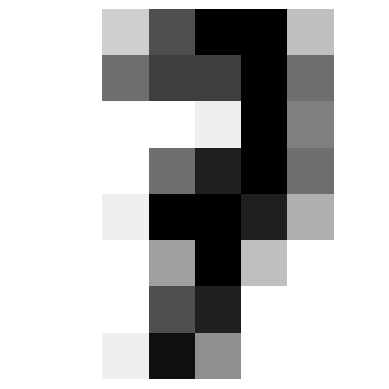

In [3]:
ex = 308

example_img = digits.images[ex]
example_num = digits.target[ex]

print(example_num)

plt.axis("off")
plt.imshow(example_img, cmap=plt.cm.gray_r, interpolation="nearest")

print(example_img)

In [4]:
model = nn.Sequential(
    nn.Linear(64, 32),
    nn.ReLU(),
    nn.Linear(32, 16),
    nn.ReLU(),
    nn.Linear(16,10)
)

In [5]:
A = torch.tensor(X, dtype=torch.float32)
B = torch.tensor(Y, dtype=torch.int64)
loss = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())
losses = []

for epoch in range(100):
  optimizer.zero_grad()
  hypothesis = model(A)
  cost = loss(hypothesis, B)
  cost.backward()
  optimizer.step()

  if epoch % 10 == 0:
    print("Epoch {:4d}/{} Cost: {:.6f}".format(epoch, 100, cost.item()))

  losses.append(cost.item())

Epoch    0/100 Cost: 2.517100
Epoch   10/100 Cost: 2.058106
Epoch   20/100 Cost: 1.722414
Epoch   30/100 Cost: 1.392874
Epoch   40/100 Cost: 1.083699
Epoch   50/100 Cost: 0.799354
Epoch   60/100 Cost: 0.579871
Epoch   70/100 Cost: 0.429817
Epoch   80/100 Cost: 0.330607
Epoch   90/100 Cost: 0.263647


Hypothesis:  [-4.599719    7.13839     5.1814957   1.9696177   0.2510889  -5.6222973
 -0.22605085 -2.5919986   1.4657733  -2.4527767 ]
Hypothesis digits:  1


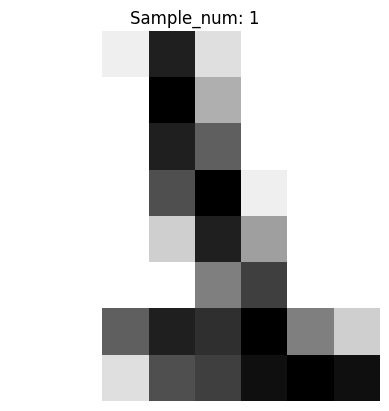

In [7]:
sample_num = 1000

with torch.no_grad():
  hypothesis = model(A[sample_num])

  result = hypothesis.detach().cpu().numpy()
  print("Hypothesis: ", result)

  h_idx = np.argmax(result)
  print("Hypothesis digits: ", h_idx)

  plt.axis("off")
  plt.imshow(digits.images[sample_num], cmap=plt.cm.gray_r, interpolation="nearest")
  plt.title("Sample_num: %i" %B[sample_num])